---
title: "Car Crashes"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Bad Drivers (US state car crashes)
- **description:** State-by-state statistics on fatal motor-vehicle collisions in the United States, covering the 50 states and the District of Columbia.
- **provenance:** FiveThirtyEight (Mona Chalabi, "Dear Mona, Which State Has The Worst Drivers?", 2015), built from NHTSA 2012 fatal-crash data (FARS) and National Association of Insurance Commissioners figures.
- **format:** long — 51 rows x 8 columns.

**Data dictionary**

- `total` — *(measurement)* The number fatal crashes per billion miles driven. Computed as fatal crashes ÷ total vehicle miles traveled, scaled by one billion for readability.
- `speeding` — *(measurement)* the percentage of fatal crashes in which drivers were speeding.
- `alcohol` — *(measurement)* the percentage of fatal crashes in which drivers were alcohol-impaired.
- `not_distracted` — *(measurement)* the percentage of fatal crashes in which drivers were not distracted.
- `no_previous` — *(measurement)* the percentage of fatal crashes in which drivers had not been involved in any previous accidents.
- `ins_premium`, `ins_losses` — *(measurement)* insurance premium and losses, in US dollars.
- `abbrev` — *(identifier)* two-letter state code.

**Structure**

- **Rows:** 51 — one row per state (plus DC).
- **Columns:** 8.
- **Identifiers:** `abbrev`.
- **Measurements:** the seven numeric columns.

**Use cases**

- scatter matrices across risk factors
- bubble scatter plots (size = a third variable)
- ranking bar charts of the worst / safest states


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

### Long form 

In [53]:
crashes = sns.load_dataset('car_crashes')
crashes.info()
crashes.head()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   total           51 non-null     float64
 1   speeding        51 non-null     float64
 2   alcohol         51 non-null     float64
 3   not_distracted  51 non-null     float64
 4   no_previous     51 non-null     float64
 5   ins_premium     51 non-null     float64
 6   ins_losses      51 non-null     float64
 7   abbrev          51 non-null     str    
dtypes: float64(7), str(1)
memory usage: 3.3 KB


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


### Long form with key index

In [54]:
crashes1 = crashes.set_index('abbrev')
crashes1.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
abbrev,,,,,,,
AL,18.8,7.332,5.640,18.048,15.040,784.55,145.08
AK,18.1,7.421,4.525,16.290,17.014,1053.48,133.93
AZ,18.6,6.510,5.208,15.624,17.856,899.47,110.35
AR,22.4,4.032,5.824,21.056,21.280,827.34,142.39
CA,12.0,4.200,3.360,10.920,10.680,878.41,165.63


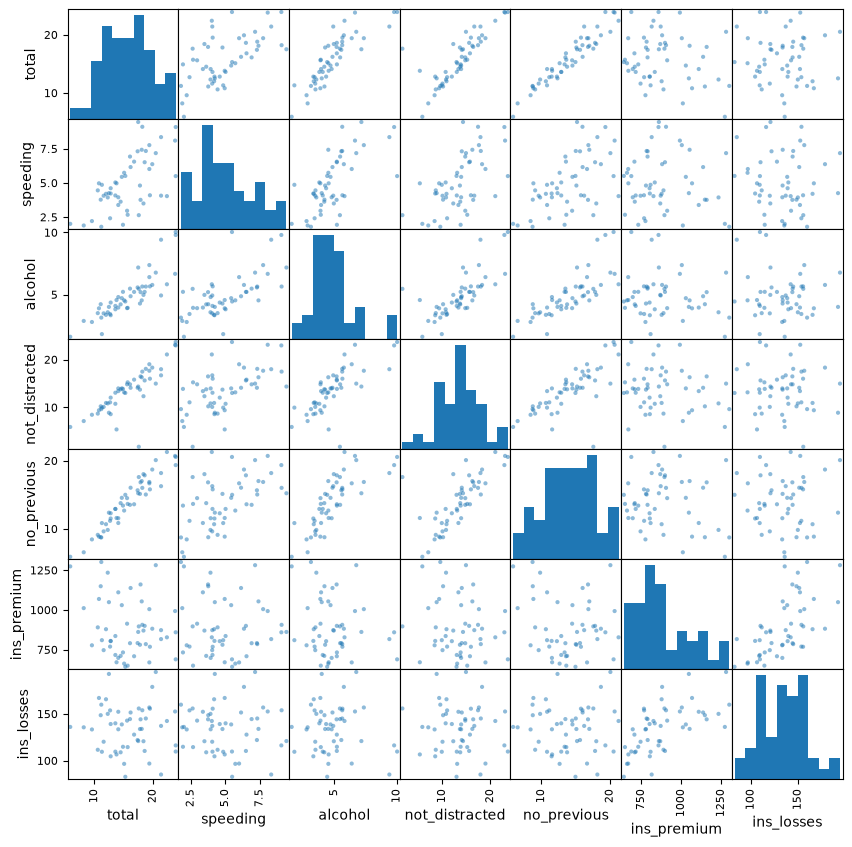

In [55]:
pd.plotting.scatter_matrix(crashes1, figsize=(10,10))
plt.show()

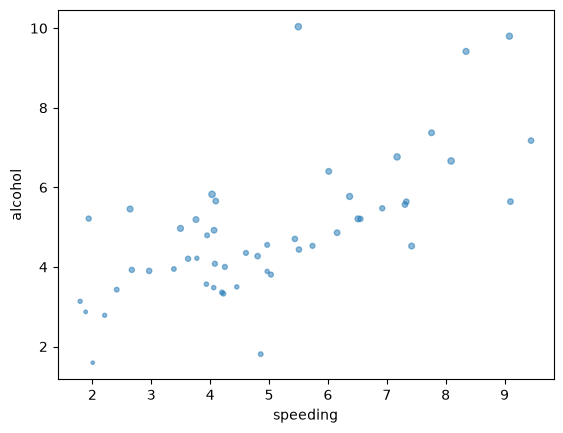

In [56]:
crashes1.plot.scatter(x='speeding', y='alcohol', s='no_previous', alpha=.5)
plt.show()

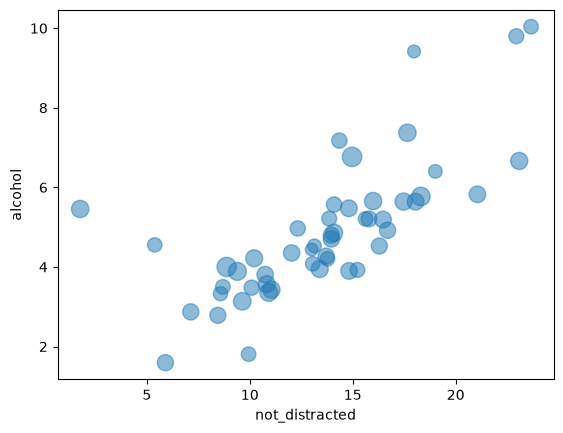

In [59]:
crashes1.plot.scatter(x='not_distracted', y='alcohol', s='ins_losses', alpha=.5)
plt.show()

In [60]:
Z = ((crashes1 - crashes1.mean()) / crashes1.std())
Z

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
abbrev,,,,,,,
AL,0.730180,1.156638,0.435603,0.992425,0.274956,-0.574368,0.426272
AK,0.560360,1.200747,-0.209229,0.602537,0.799304,0.933964,-0.022674
AZ,0.681660,0.749253,0.185767,0.454831,1.022962,0.070177,-0.972106
AR,1.603542,-0.478849,0.542015,1.659539,1.932471,-0.334374,0.317961
CA,-0.919504,-0.395588,-0.882977,-0.588421,-0.883180,-0.047941,1.253703
CO,-0.531343,0.016753,-0.623887,-0.627454,-0.288174,-0.288608,0.218106
CT,-1.210624,-0.014965,-0.577621,-0.926413,-1.367684,1.019496,1.309670
DE,0.099419,0.573810,-0.015490,0.115508,0.540052,1.407278,0.683963
DC,-2.399367,-1.482939,-1.904876,-1.701755,-2.152879,2.170165,0.062686


In [65]:
def label_plot(df, x, y):
    fig, ax = plt.subplots()
    ax.set_xlim([df[x].min()-.25, df[x].max()])
    ax.set_ylim([df[y].min()-.25, df[y].max()])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    for idx, row in df.iterrows():
        ax.text(row[x], row[y], idx)
    sns.despine(left=True, bottom=True)
    ax.axvline(0, color='gray', ls='--', lw=.5)
    ax.axhline(0, color='gray', ls='--', lw=.5)
    plt.show()

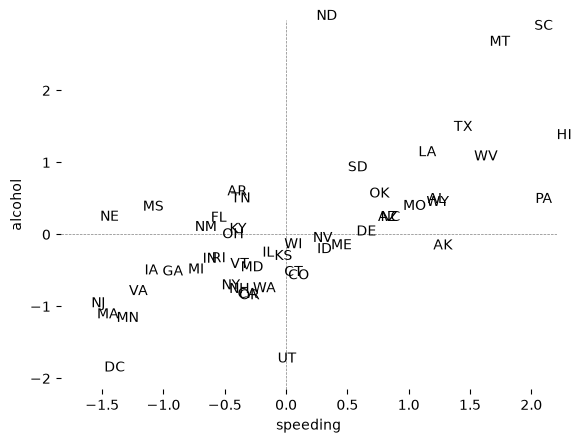

In [68]:
label_plot(Z, x = 'speeding', y = 'alcohol')

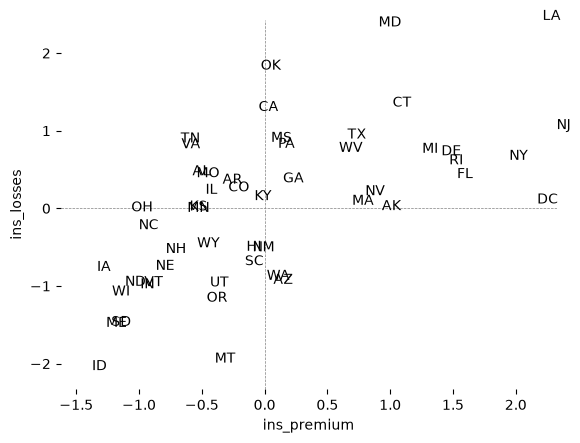

In [69]:
label_plot(Z, x = 'ins_premium', y = 'ins_losses')

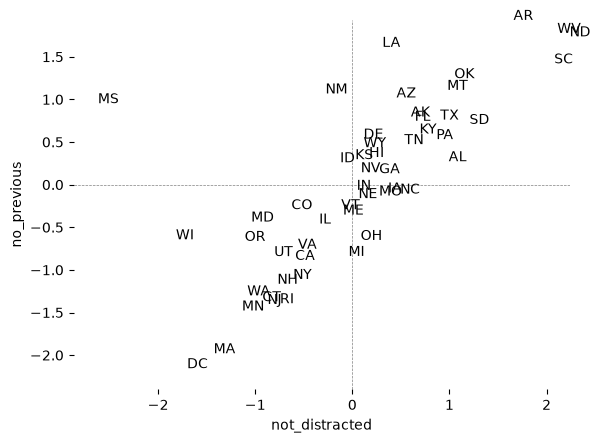

In [76]:
label_plot(Z, x = 'not_distracted', y = 'no_previous')

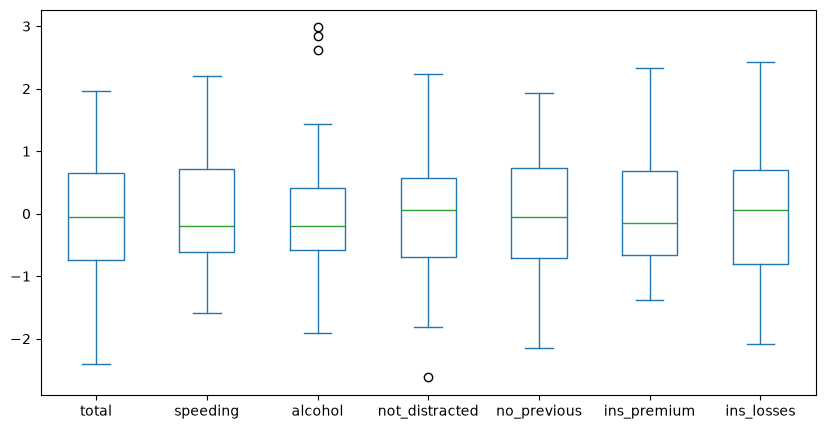

In [70]:
Z.plot.box(figsize=(10,5))
plt.show()

In [75]:
crashes1.corr().style.format(precision=2).background_gradient(cmap='Spectral_r')

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
total,1.00,0.61,0.85,0.83,0.96,-0.20,-0.04
speeding,0.61,1.00,0.67,0.59,0.57,-0.08,-0.07
alcohol,0.85,0.67,1.00,0.73,0.78,-0.17,-0.11
not_distracted,0.83,0.59,0.73,1.00,0.75,-0.17,-0.08
no_previous,0.96,0.57,0.78,0.75,1.00,-0.16,-0.01
ins_premium,-0.20,-0.08,-0.17,-0.17,-0.16,1.00,0.62
ins_losses,-0.04,-0.07,-0.11,-0.08,-0.01,0.62,1.00


<Axes: ylabel='f1,f2'>

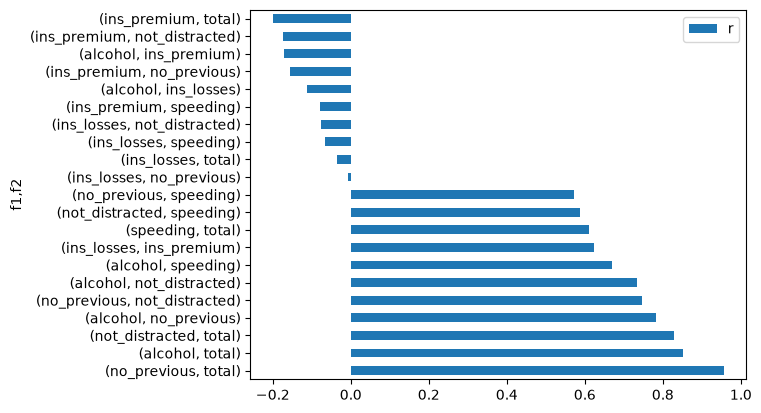

In [88]:
crashes_corr = crashes1.corr().stack().to_frame('r')
crashes_corr.index.names = ['f1', 'f2']
crashes_corr.query("f2 > f1").sort_values('r', ascending=False).plot.barh()

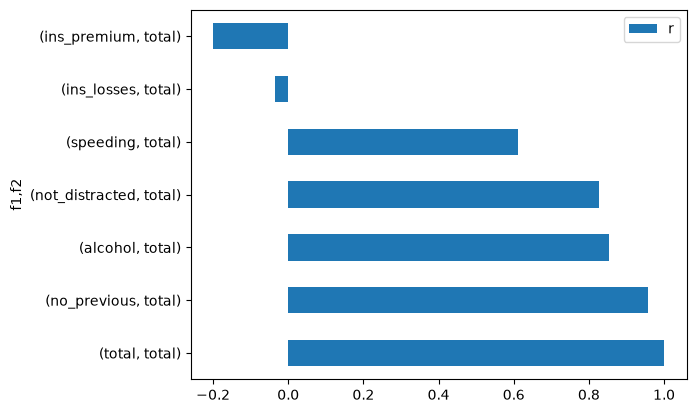

In [90]:
crashes_corr.query("f2 == 'total'").sort_values('r', ascending=False).plot.barh()
plt.show()